In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE




In [16]:
df=pd.read_csv("creditcard.csv")

In [17]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## <a id="42">Check missing data</a>  

In [ ]:
df.isnull().sum()

1081


In [18]:
total = df.isnull().sum().sort_values(ascending = False)
percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).transpose()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:

fraud  = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print(f"\n  Sound operations : {len(normal):,}  ({len(normal)/len(df)*100:.2f}%)")
print(f"  Scams: {len(fraud):,}   ({len(fraud)/len(df)*100:.2f}%)")
print(f"\n  Average sound amount : ${normal['Amount'].mean():.2f}")
print(f"  Average amount of fraud ${fraud['Amount'].mean():.2f}")
print(f"\n Missing values: {df.isnull().sum().sum()}")
print(f"  Duplicate records: {df.duplicated().sum()}")



  Sound operations : 284,315  (99.83%)
  Scams: 492   (0.17%)

  Average sound amount : $88.29
  Average amount of fraud $122.21

 Missing values: 0
  Duplicate records: 1081


## EDA

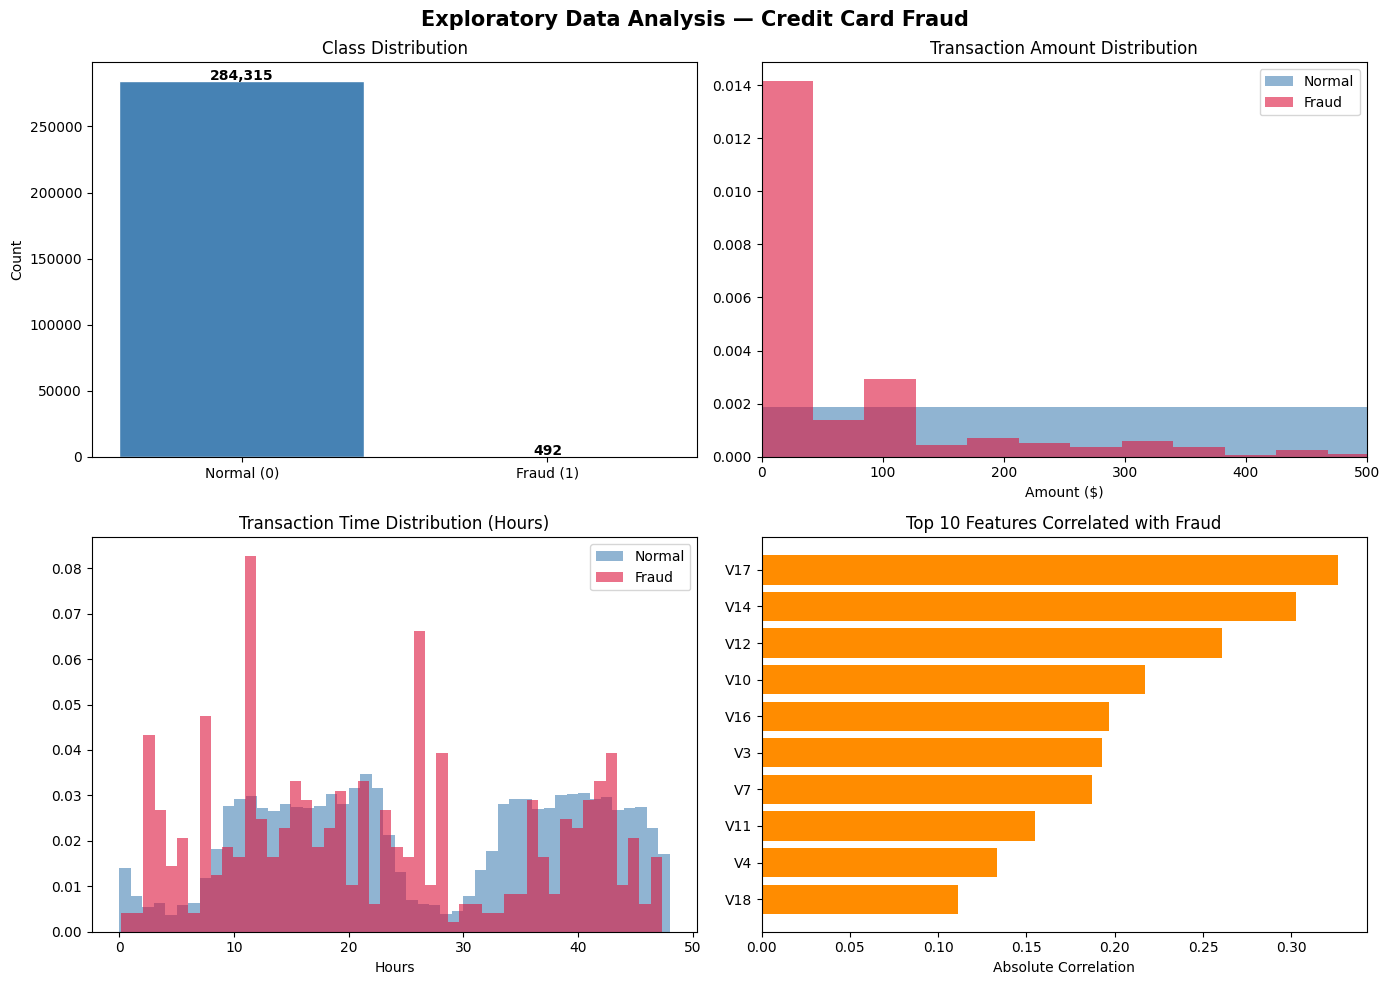

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — Credit Card Fraud', fontsize=15, fontweight='bold')

# 1. Class Distribution
axes[0,0].bar(['Normal (0)', 'Fraud (1)'],
              [len(normal), len(fraud)],
              color=['steelblue','crimson'], edgecolor='white')
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')
for i, v in enumerate([len(normal), len(fraud)]):
    axes[0,0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# 2. Amount Distribution
axes[0,1].hist(normal['Amount'], bins=50, alpha=0.6, color='steelblue', label='Normal', density=True)
axes[0,1].hist(fraud['Amount'],  bins=50, alpha=0.6, color='crimson',   label='Fraud',  density=True)
axes[0,1].set_title('Transaction Amount Distribution')
axes[0,1].set_xlabel('Amount ($)')
axes[0,1].legend()
axes[0,1].set_xlim(0, 500)

# 3. Time Distribution
axes[1,0].hist(normal['Time']/3600, bins=48, alpha=0.6, color='steelblue', label='Normal', density=True)
axes[1,0].hist(fraud['Time']/3600,  bins=48, alpha=0.6, color='crimson',   label='Fraud',  density=True)
axes[1,0].set_title('Transaction Time Distribution (Hours)')
axes[1,0].set_xlabel('Hours')
axes[1,0].legend()

# 4. Top Correlated Features with Class
corr = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
axes[1,1].barh(corr.index[::-1], corr.values[::-1], color='darkorange')
axes[1,1].set_title('Top 10 Features Correlated with Fraud')
axes[1,1].set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.show()


### معالجة Imbalanced Data بـ SMOTE
المشكلة: 99.83% سليمة و 0.17% احتيال فقط  
الحل: SMOTE يولد عينات اصطناعية من الاحتيال لتوازن البيانات

In [ ]:

scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df.drop(['Amount', 'Time'], axis=1, inplace=True)


X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f" Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"   Fraud in train: {y_train.sum():,} | Fraud in test: {y_test.sum():,}")


smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\n After SMOTE:")
print(f"   Normal : {(y_train_sm==0).sum():,}")
print(f"   Fraud  : {(y_train_sm==1).sum():,}")

 Train: 227,845 | Test: 56,962
   Fraud in train: 394 | Fraud in test: 98

 After SMOTE:
   Normal : 227,451
   Fraud  : 227,451


## Train All Models

In [36]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
}

results = {}

for name, model in models.items():
    print(f" Training {name}...", end=' ')
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model':         model,
        'y_pred':        y_pred,
        'y_prob':        y_prob,
        'roc_auc':       roc_auc_score(y_test, y_prob),
        'avg_precision': average_precision_score(y_test, y_prob),
    }
    print(f"Done! ROC-AUC: {results[name]['roc_auc']:.4f}")

print("\n All models trained!")

 Training Logistic Regression... Done! ROC-AUC: 0.9698
 Training Random Forest... Done! ROC-AUC: 0.9688
 Training XGBoost... Done! ROC-AUC: 0.9792

 All models trained!


In [37]:
for name, r in results.items():
    print(f"\n{'='*50}")
    print(f"── {name} ──")
    print(classification_report(y_test, r['y_pred'], target_names=['Normal', 'Fraud']))


── Logistic Regression ──
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


── Random Forest ──
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962


── XGBoost ──
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

    accuracy                           1.00     56962
   macro avg       0.87      0.94      0.90     56962
weighted av

### ROC Curves

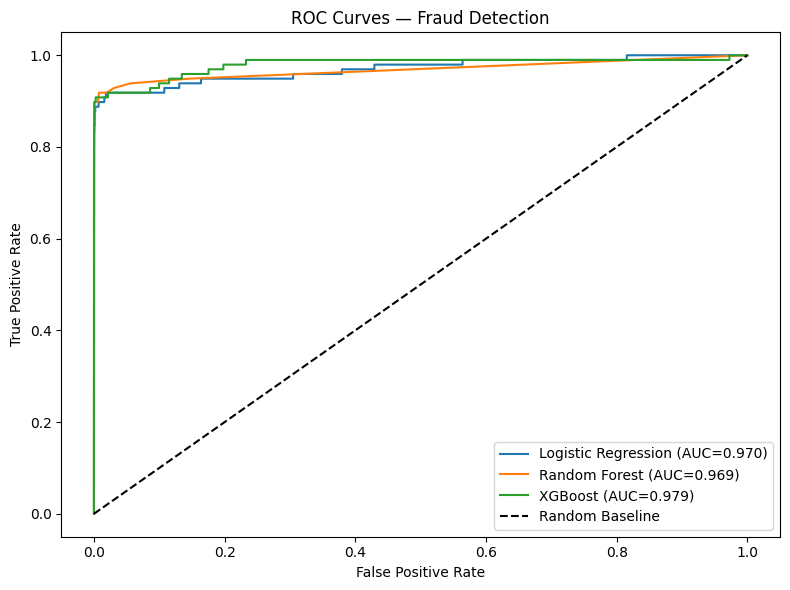

In [38]:
plt.figure(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Fraud Detection')
plt.legend()
plt.tight_layout()
plt.show()

### Precision-Recall Curves (الأهم في Fraud Detection)

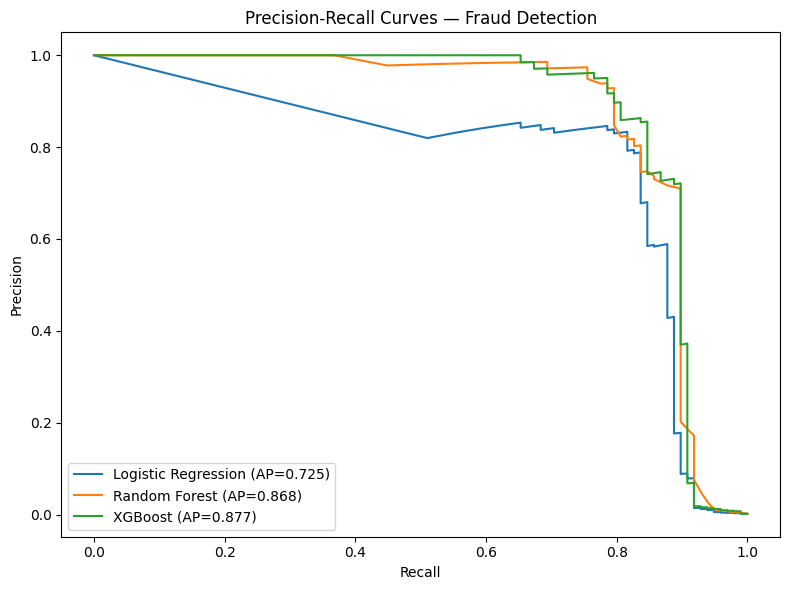

In [39]:
plt.figure(figsize=(8, 6))
for name, r in results.items():
    precision, recall, _ = precision_recall_curve(y_test, r['y_prob'])
    plt.plot(recall, precision, label=f"{name} (AP={r['avg_precision']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves — Fraud Detection')
plt.legend()
plt.tight_layout()
plt.show()

### Confusion Matrices

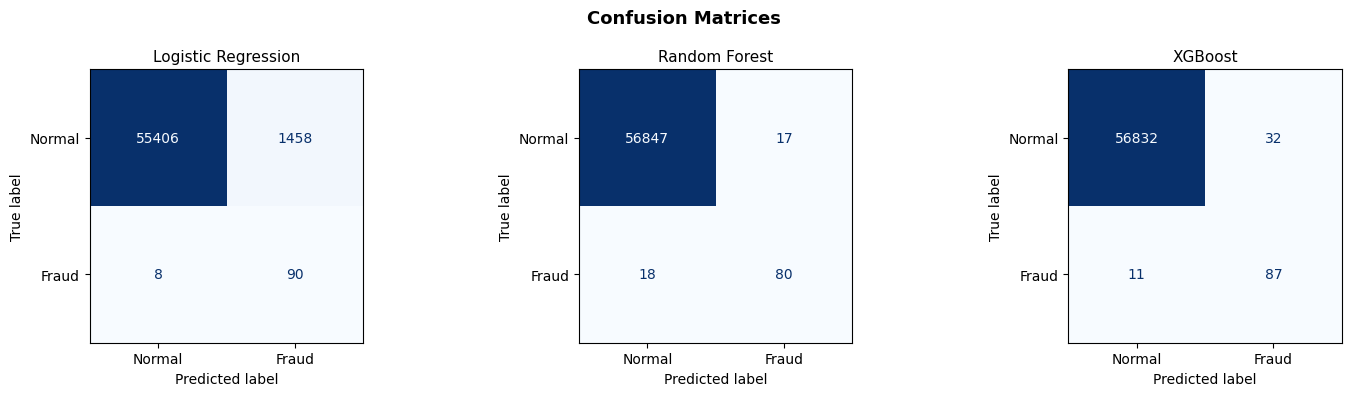

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Normal','Fraud']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##  Best model for predict

In [46]:
best_name  = max(results, key=lambda x: results[x]['roc_auc'])
best_model = results[best_name]['model']

print(f"   Best Model: {best_name}")
print(f"   ROC-AUC        : {results[best_name]['roc_auc']:.4f}")
print(f"   Avg Precision  : {results[best_name]['avg_precision']:.4f}")

def predict_transaction(features, model):
    arr  = np.array(features).reshape(1, -1)
    prob = model.predict_proba(arr)[0][1]
    result = " FRAUD" if prob > 0.5 else " Normal"
    print(f"  Result            : {result}")
    print(f"  Potential for fraud : {prob*100:.2f}%")
    return result, prob

print("\n" + "="*50)
print(" Testing a sound process:")
predict_transaction(X_test[y_test == 0].iloc[0].values, best_model)

print("\n" + "="*50)
print(" Testing a fraud operation:")
predict_transaction(X_test[y_test == 1].iloc[0].values, best_model)

   Best Model: XGBoost
   ROC-AUC        : 0.9792
   Avg Precision  : 0.8774

 Testing a sound process:
  Result            :  Normal
  Potential for fraud : 0.00%

 Testing a fraud operation:
  Result            :  FRAUD
  Potential for fraud : 100.00%


(' FRAUD', np.float32(0.99998355))